In [12]:
#! pip install pandas
#! pip install missingno
#! pip install glob

In [47]:
import glob
import missingno as mno
import pandas as pd
import numpy as np

In [48]:
list_data_set = glob.glob('*.csv', recursive=True)

In [49]:
print(list_data_set)

['diet_recommendations_dataset.csv', 'exercices.csv', 'daily_food_nutrition_dataset.csv', 'gym_meber.csv']


In [50]:
df_food = pd.read_csv("daily_food_nutrition_dataset.csv", on_bad_lines='skip')
df_diet = pd.read_csv('diet_recommendations_dataset.csv', on_bad_lines='skip')
df_members = pd.read_csv('gym_meber.csv', on_bad_lines='skip')
df_tracker = pd.read_csv('exercices.csv', on_bad_lines='skip')
df_merge_exer = pd.concat([df_members, df_tracker], axis=0)

In [51]:
list_df = [
    df_food, 
    df_diet, 
    df_merge_exer
]


In [52]:
for i in list_df:
    print(i.columns)
    

Index(['Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)',
       'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)',
       'Sodium (mg)', 'Cholesterol (mg)', 'Meal_Type', 'Water_Intake (ml)'],
      dtype='str')
Index(['Patient_ID', 'Age', 'Gender', 'Weight_kg', 'Height_cm', 'BMI',
       'Disease_Type', 'Severity', 'Physical_Activity_Level',
       'Daily_Caloric_Intake', 'Cholesterol_mg/dL', 'Blood_Pressure_mmHg',
       'Glucose_mg/dL', 'Dietary_Restrictions', 'Allergies',
       'Preferred_Cuisine', 'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan',
       'Dietary_Nutrient_Imbalance_Score', 'Diet_Recommendation'],
      dtype='str')
Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='str')


In [53]:
for i in list_df:
    print(i.shape)

(645, 12)
(1000, 20)
(2773, 15)


In [54]:
for i in list_df:
    print(i.isna().sum() , "\n")

Food_Item            0
Category             0
Calories (kcal)      0
Protein (g)          0
Carbohydrates (g)    0
Fat (g)              0
Fiber (g)            0
Sugars (g)           0
Sodium (mg)          0
Cholesterol (mg)     0
Meal_Type            0
Water_Intake (ml)    0
dtype: int64 

Patient_ID                            0
Age                                   0
Gender                                0
Weight_kg                             0
Height_cm                             0
BMI                                   0
Disease_Type                        204
Severity                              0
Physical_Activity_Level               0
Daily_Caloric_Intake                  0
Cholesterol_mg/dL                     0
Blood_Pressure_mmHg                   0
Glucose_mg/dL                         0
Dietary_Restrictions                334
Allergies                           323
Preferred_Cuisine                     0
Weekly_Exercise_Hours                 0
Adherence_to_Diet_Plan       

In [55]:
for i in list_df:
    for j in i.columns:
        if i[j].dtypes == "str":
            print(j + "\n")
            print(i[j].unique())
            print('\n')
    print("\n NOUVEAU DATASET \n")

Food_Item

<StringArray>
[      'Scrambled Eggs (2 large)',    'Whole Wheat Toast (1 slice)',
                 'Coffee (black)',                         'Banana',
          'Grilled Chicken Salad',                          'Apple',
           'Salmon (4oz grilled)',          'Quinoa (1 cup cooked)',
       'Steamed Broccoli (1 cup)',     'Greek Yogurt (plain 1 cup)',
 ...
   'Turkish Coffee (1 small cup)',           'Cardamom (in coffee)',
       'Shish Tawook (2 skewers)',     'Garlic Sauce (Toum 1 tbsp)',
            'French Fries (side)',     'Pickled Cucumber (1/4 cup)',
      'Fattoush Salad (1.5 cups)', 'Fried Pita (1/2 pita in salad)',
       'Sumac (1/2 tsp dressing)',   'Pomegranate Molasses (1 tsp)']
Length: 587, dtype: str


Category

<StringArray>
[       'Protein/Dairy',                'Grain',             'Beverage',
                'Fruit',         'Meal/Protein',         'Protein/Fish',
            'Vegetable',                'Dairy',                  'Nut',
       'Mea

In [56]:

for j in df_merge_exer.columns:
    if df_merge_exer[j].dtypes == "str":
        print(j + "\n")
        print(df_merge_exer[j].unique())
        print('\n')

Gender

<StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str


Workout_Type

<StringArray>
['Yoga', 'HIIT', 'Cardio', 'Strength', nan, '\nStrength', '\tCardio',
 '\tYoga']
Length: 8, dtype: str




In [57]:
# nettoyage des données de type string
for j in list_df:
    for i in j.columns:
        if j[i].dtypes == "str" or j[i].dtypes == "object":
            #j[i] = j[i].str.replace("\n","", regex=False)
            #j[i] = j[i].str.replace("\t","", regex=False)
            print("execution")
            j[i] = j[i].str.replace("\\t","", regex=False)
            j[i] = j[i].str.replace("\\n","", regex=False)
            

execution
execution
execution
execution
execution
execution
execution
execution
execution
execution
execution
execution
execution
execution
execution


In [58]:
for i in list_df:
    print("\n NOUVEAU DATASET \n")
    for j in i.columns:
        #if i[j].dtypes == "str" or i[j].dtypes == "object" :
            print(j + "\n")
            print(i[j].unique())
            print('\n')
    


 NOUVEAU DATASET 

Food_Item

<StringArray>
[      'Scrambled Eggs (2 large)',    'Whole Wheat Toast (1 slice)',
                 'Coffee (black)',                         'Banana',
          'Grilled Chicken Salad',                          'Apple',
           'Salmon (4oz grilled)',          'Quinoa (1 cup cooked)',
       'Steamed Broccoli (1 cup)',     'Greek Yogurt (plain 1 cup)',
 ...
   'Turkish Coffee (1 small cup)',           'Cardamom (in coffee)',
       'Shish Tawook (2 skewers)',     'Garlic Sauce (Toum 1 tbsp)',
            'French Fries (side)',     'Pickled Cucumber (1/4 cup)',
      'Fattoush Salad (1.5 cups)', 'Fried Pita (1/2 pita in salad)',
       'Sumac (1/2 tsp dressing)',   'Pomegranate Molasses (1 tsp)']
Length: 587, dtype: str


Category

<StringArray>
[       'Protein/Dairy',                'Grain',             'Beverage',
                'Fruit',         'Meal/Protein',         'Protein/Fish',
            'Vegetable',                'Dairy',                

In [59]:
for i in list_df:
    print("\n\n NOUVEAU \n\n")
    print(i.describe())



 NOUVEAU 


       Calories (kcal)  Protein (g)  Carbohydrates (g)     Fat (g)  \
count       645.000000   645.000000         645.000000  645.000000   
mean        146.294574     6.300620          15.435194    6.469612   
std         139.984360     8.782683          16.349230    8.142916   
min           0.000000     0.000000           0.000000    0.000000   
25%          42.000000     0.500000           1.300000    0.200000   
50%         105.000000     2.700000           9.200000    3.000000   
75%         200.000000     7.000000          27.000000   10.000000   
max         680.000000    45.000000          70.000000   40.000000   

        Fiber (g)  Sugars (g)  Sodium (mg)  Cholesterol (mg)  \
count  645.000000  645.000000   645.000000        645.000000   
mean     1.702481    5.294264   246.331783         20.482171   
std      2.121275    8.537343   308.472431         43.560072   
min      0.000000    0.000000     0.000000          0.000000   
25%      0.000000    0.400000     5

In [60]:
for i in list_df :
    print("\n\n NOUVEAU \n\n")
    print(i.isnull().mean())
    



 NOUVEAU 


Food_Item            0.0
Category             0.0
Calories (kcal)      0.0
Protein (g)          0.0
Carbohydrates (g)    0.0
Fat (g)              0.0
Fiber (g)            0.0
Sugars (g)           0.0
Sodium (mg)          0.0
Cholesterol (mg)     0.0
Meal_Type            0.0
Water_Intake (ml)    0.0
dtype: float64


 NOUVEAU 


Patient_ID                          0.000
Age                                 0.000
Gender                              0.000
Weight_kg                           0.000
Height_cm                           0.000
BMI                                 0.000
Disease_Type                        0.204
Severity                            0.000
Physical_Activity_Level             0.000
Daily_Caloric_Intake                0.000
Cholesterol_mg/dL                   0.000
Blood_Pressure_mmHg                 0.000
Glucose_mg/dL                       0.000
Dietary_Restrictions                0.334
Allergies                           0.323
Preferred_Cuisine          

In [61]:
df_merge_exer = df_merge_exer.dropna()
df_merge_exer.shape

(1359, 15)

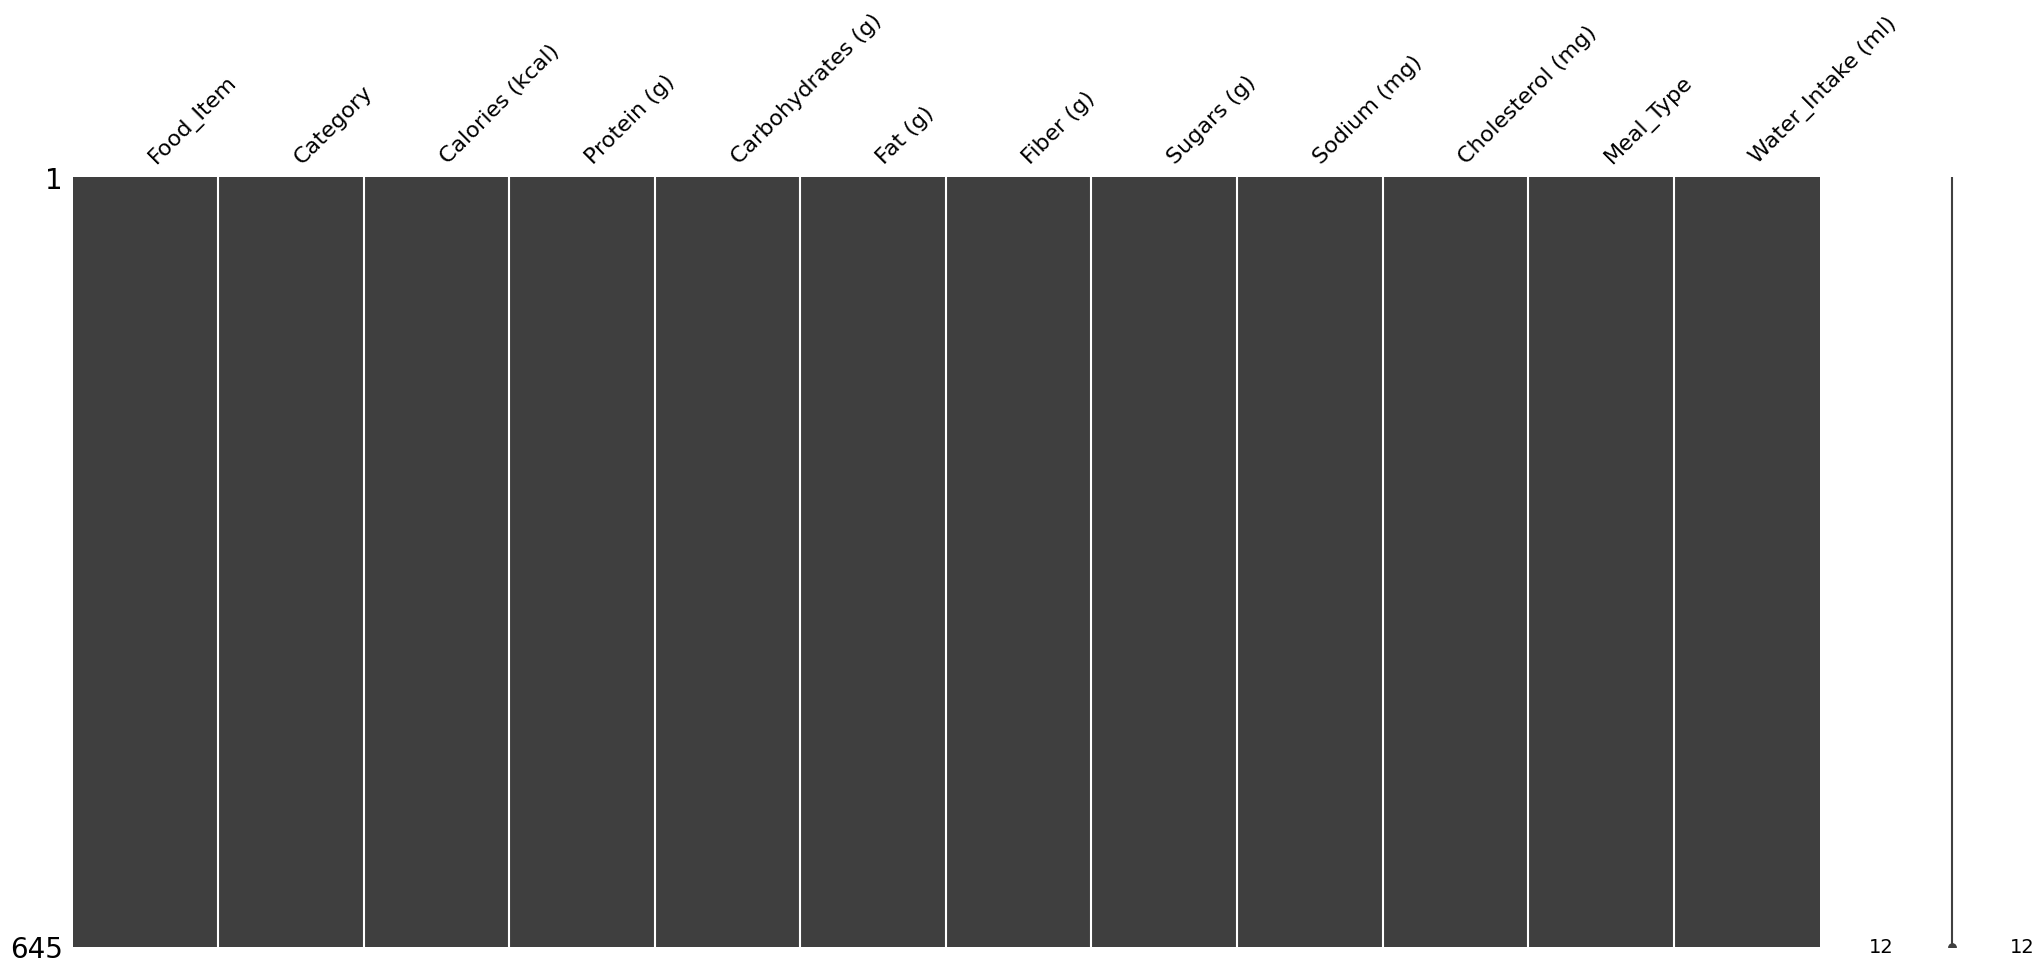

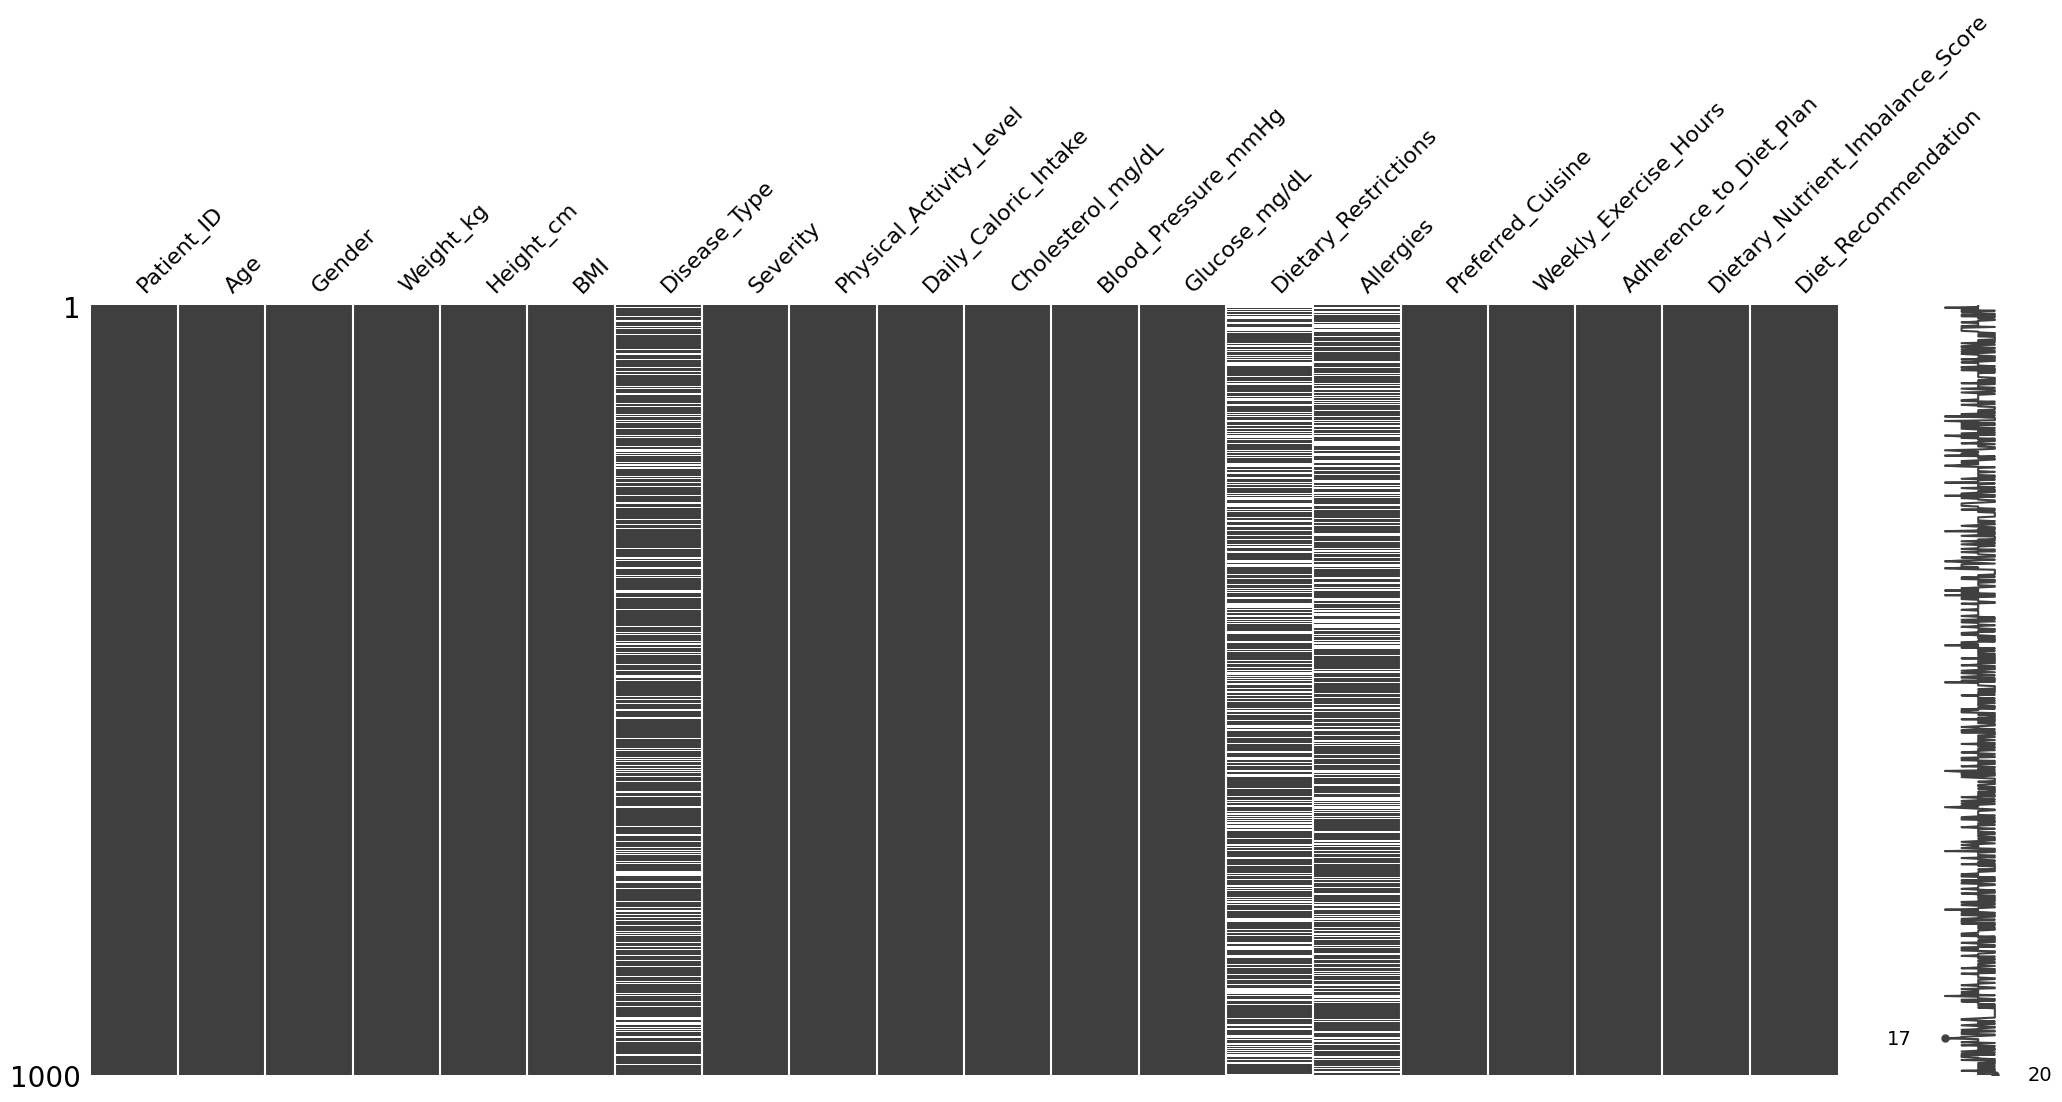

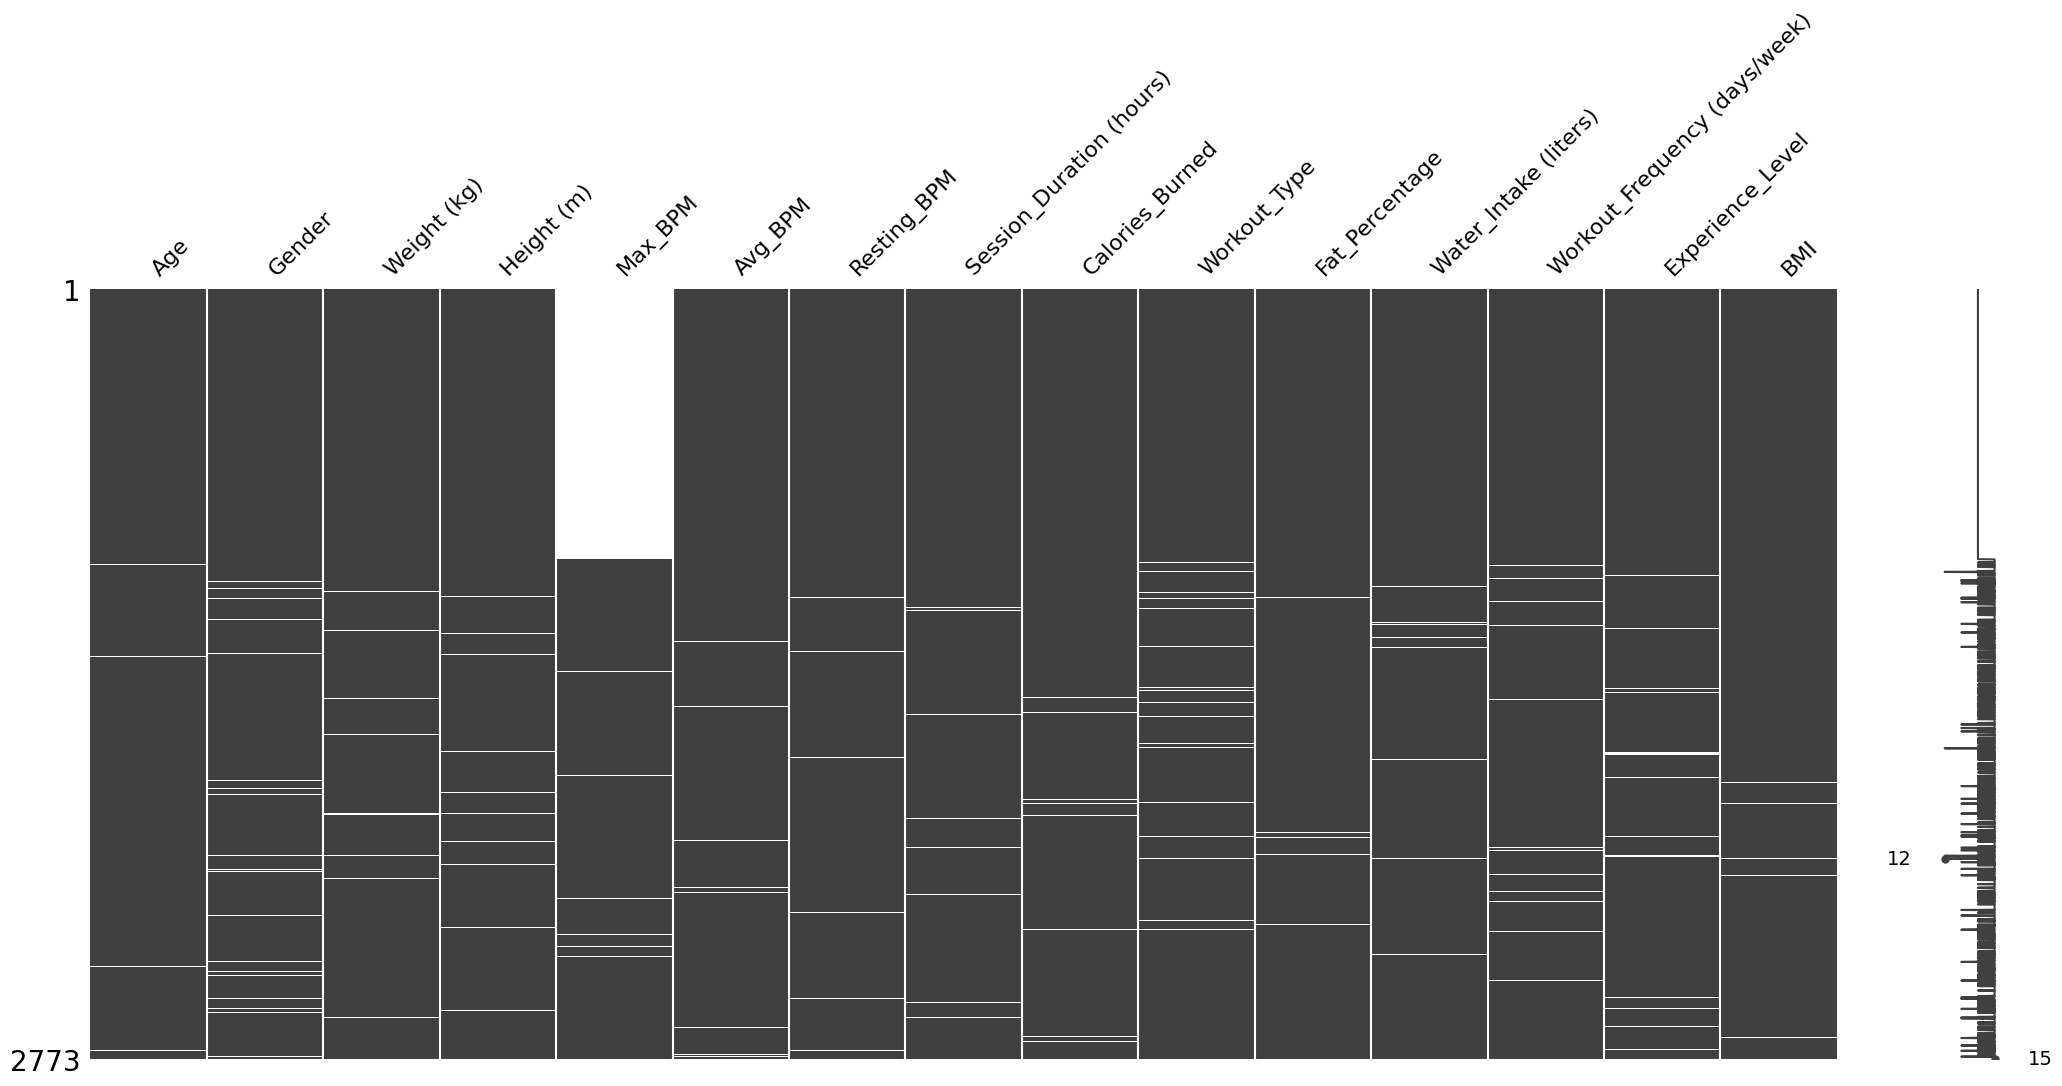

In [62]:
for i in list_df:
    mno.matrix(i)

In [63]:
df_merge_exer.dtypes

Age                              float64
Gender                               str
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                           object
Avg_BPM                          float64
Resting_BPM                      float64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                         str
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)    float64
Experience_Level                 float64
BMI                              float64
dtype: object

In [64]:
for i in list_df:
    for j in i.columns:
         if j == "Max_BPM" :
            i[j] =  pd.to_numeric(i[j], errors='coerce')

condition = df_merge_exer['BMI'].isna()# | df_merge_exer['Weight (kg)'].isna() | df_merge_exer['Height (m)'].isna()

df_BMI_W_H_NAN = df_merge_exer[df_merge_exer['BMI'] == np.nan]

df_BMI_W_H_NAN.shape

(0, 15)

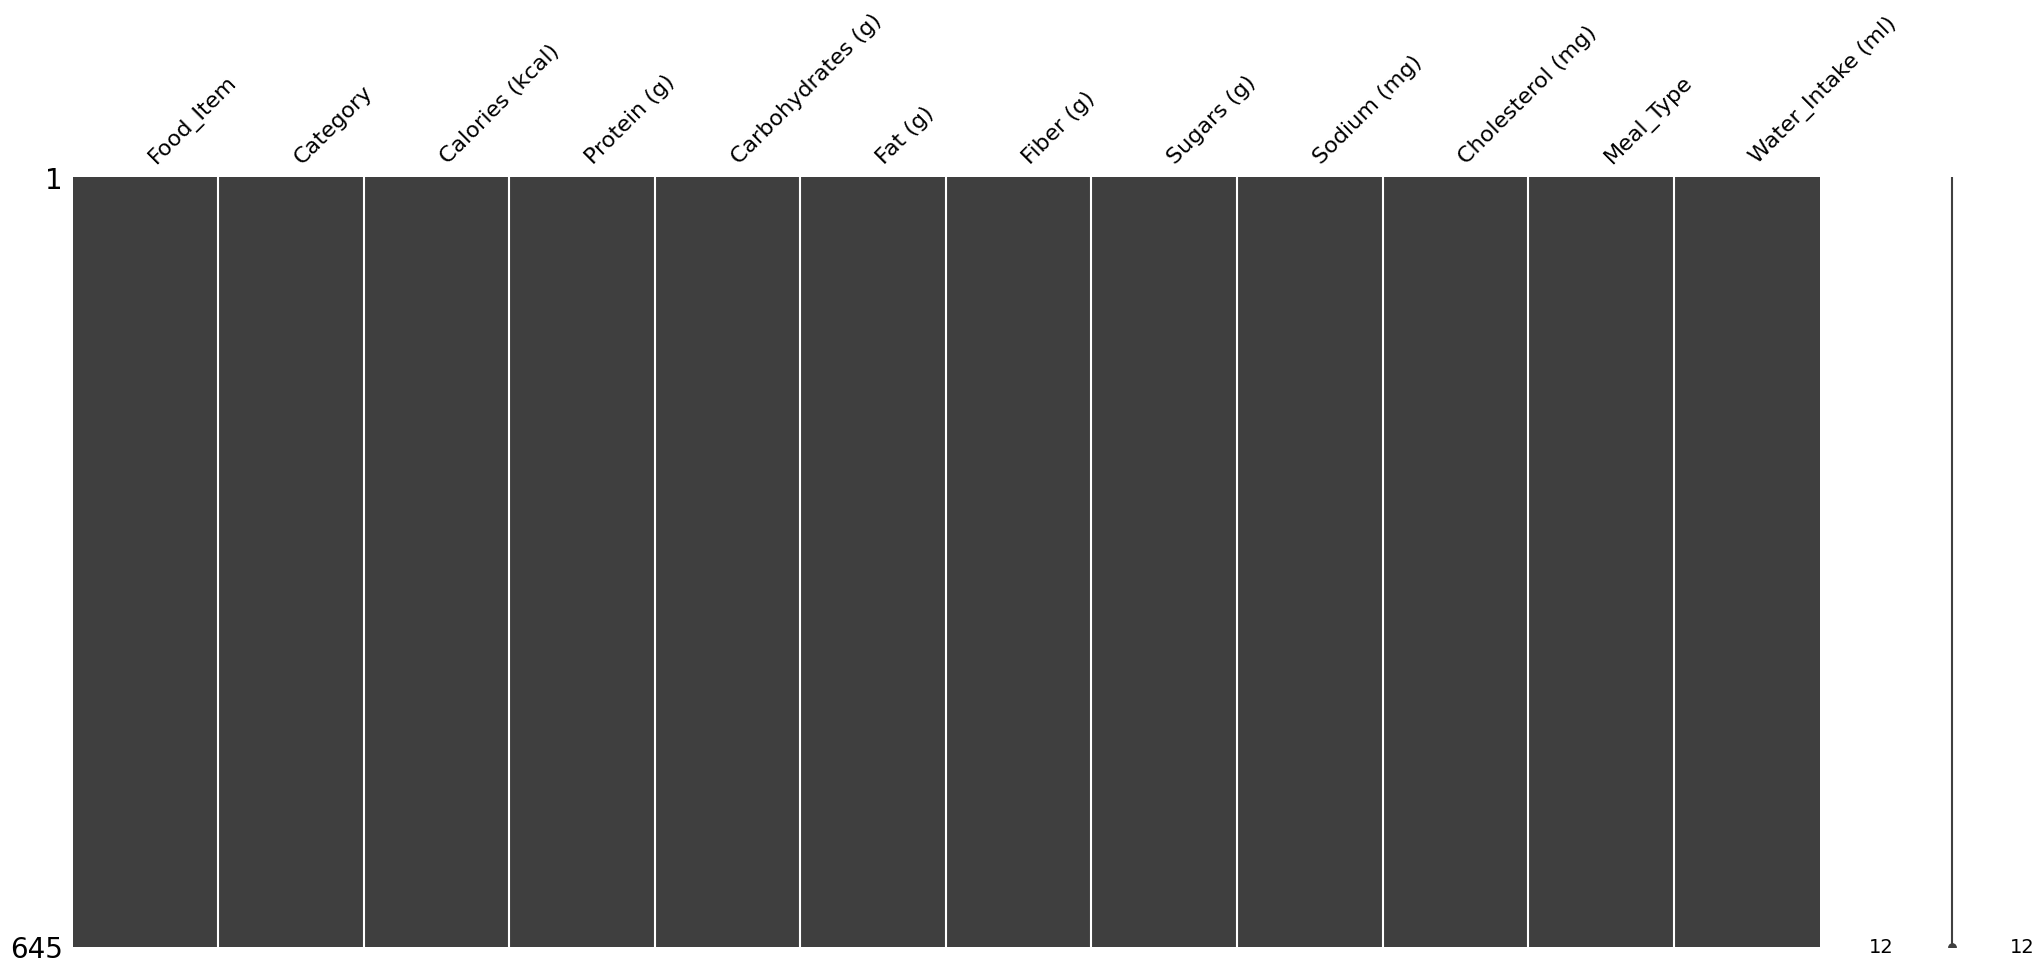

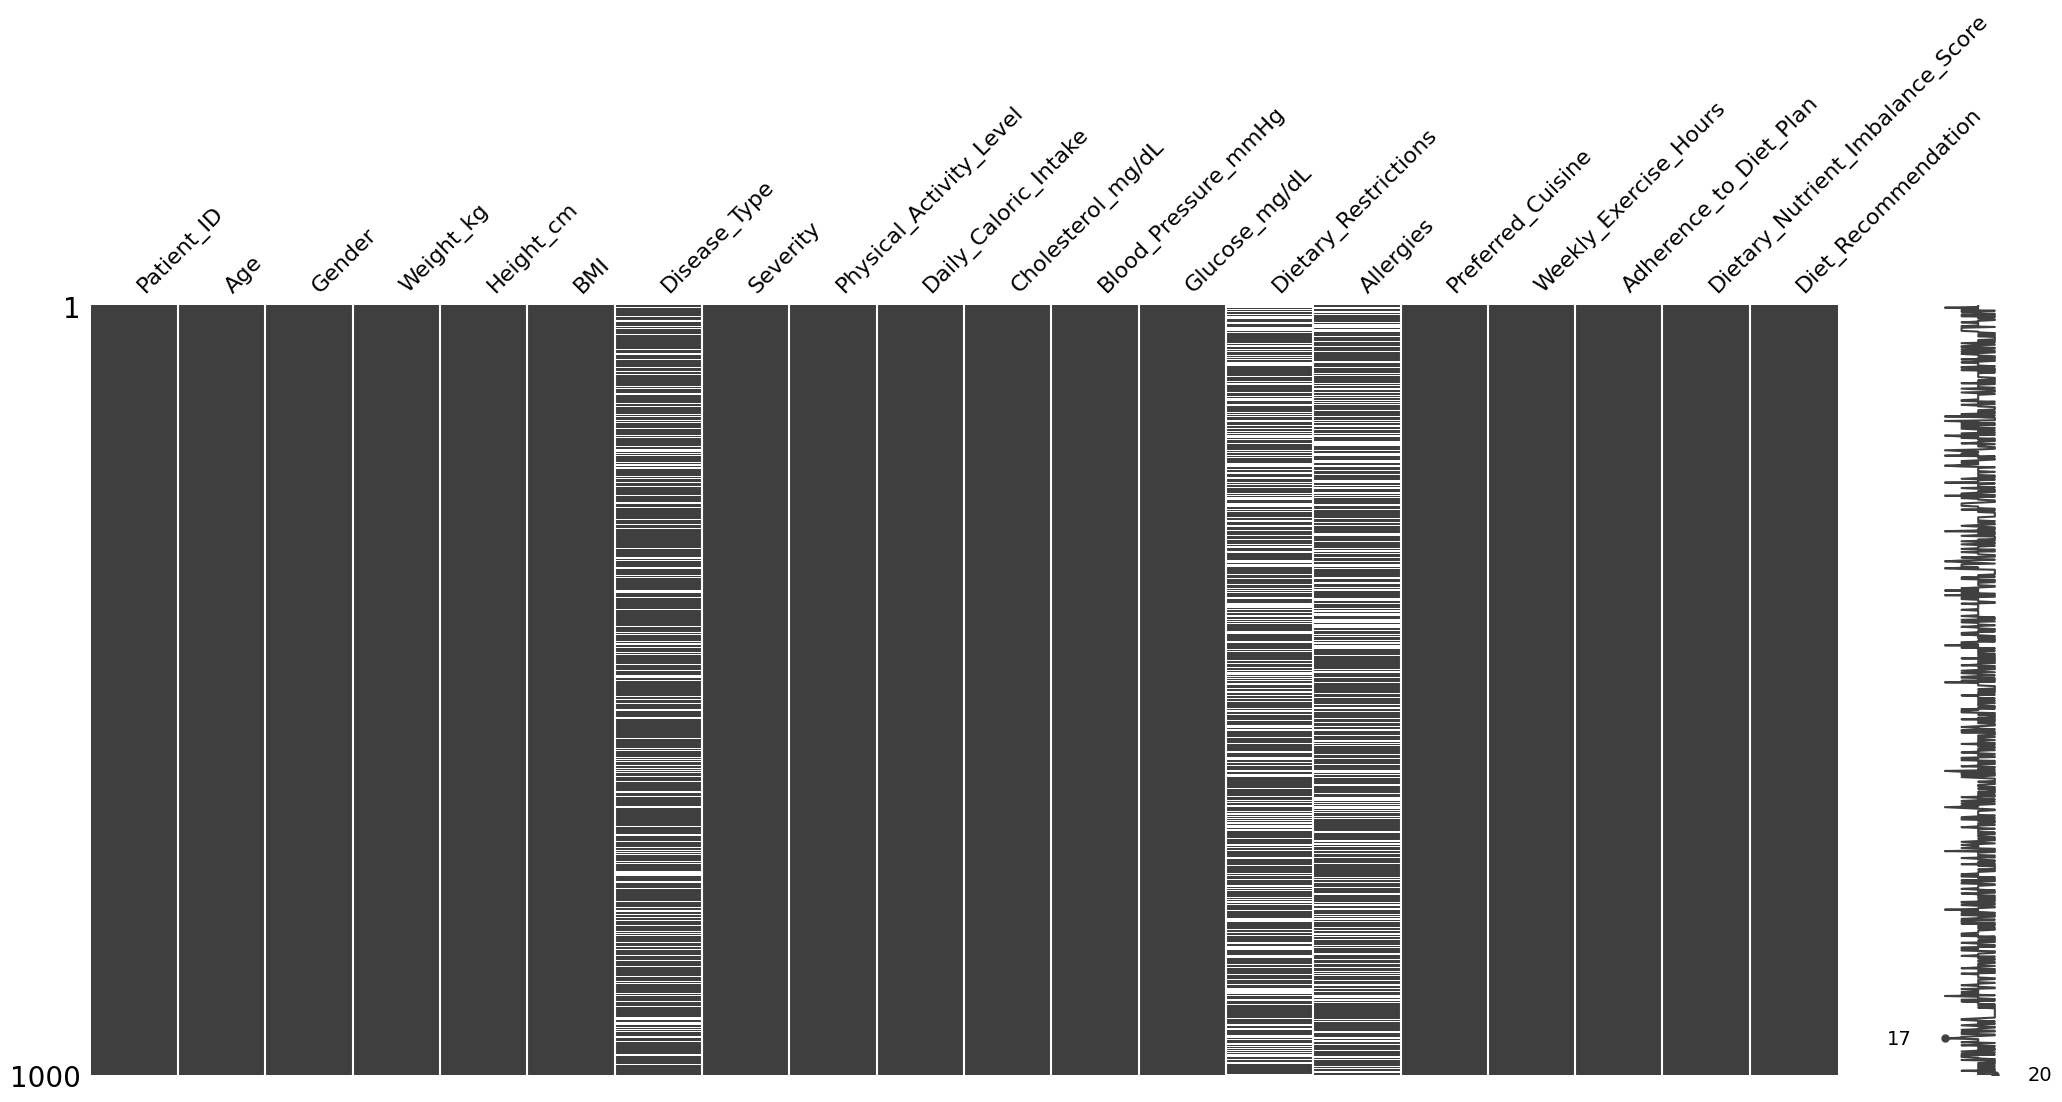

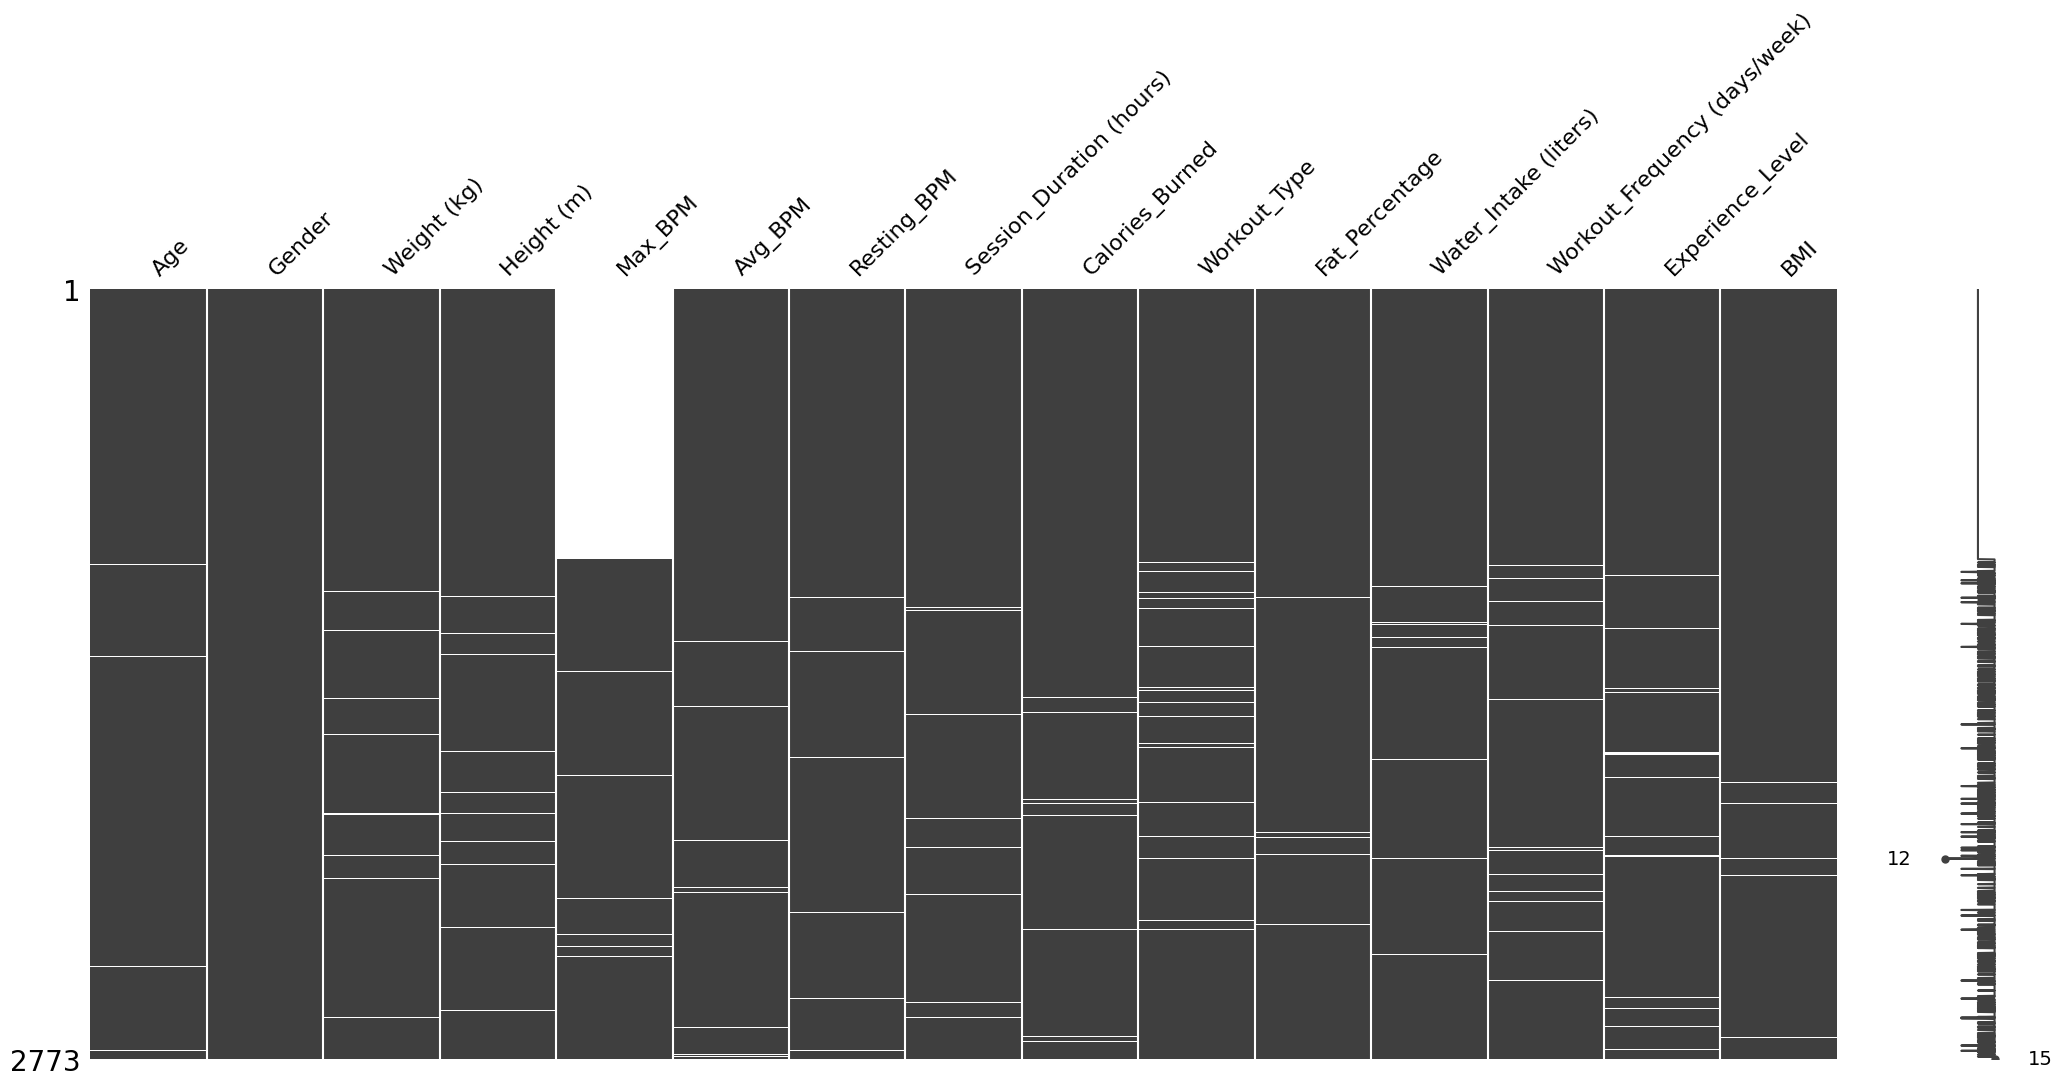

In [65]:
for i in list_df:
    for j in i.columns:
        if j == "Gender" :
            i[j] = i[j].fillna("Other")
        #elif i[j].dtype in[ "float64", "int64"]:
        #    i[j] = i[j].fillna(i[j].median())
    mno.matrix(i)

## les deux derniers datasets ont les même colonnes donc on va pouvoir les fusiner/concatener

In [66]:

df_merge_exer.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='str')

In [86]:
df_merge_exer.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,34.0,Female,86.7,1.86,174,152.0,74.0,1.12,712.0,Strength,12.8,2.4,5.0,2.0,14.31
1,26.0,Female,84.7,1.83,166,156.0,73.0,1.00,833.0,Strength,27.9,2.8,5.0,2.0,33.49
2,22.0,Male,64.8,1.85,187,166.0,64.0,1.24,1678.0,Cardio,28.7,1.9,3.0,2.0,12.73
3,54.0,Female,75.3,1.82,187,169.0,58.0,1.45,628.0,Cardio,31.8,2.4,4.0,1.0,20.37
4,34.0,Female,52.8,1.74,177,169.0,66.0,1.60,1286.0,Strength,26.4,3.2,4.0,2.0,20.83


In [87]:
df_merge_exer.info()

<class 'pandas.DataFrame'>
Index: 1359 entries, 0 to 1799
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            1359 non-null   float64
 1   Gender                         1359 non-null   str    
 2   Weight (kg)                    1359 non-null   float64
 3   Height (m)                     1359 non-null   float64
 4   Max_BPM                        1359 non-null   object 
 5   Avg_BPM                        1359 non-null   float64
 6   Resting_BPM                    1359 non-null   float64
 7   Session_Duration (hours)       1359 non-null   float64
 8   Calories_Burned                1359 non-null   float64
 9   Workout_Type                   1359 non-null   str    
 10  Fat_Percentage                 1359 non-null   float64
 11  Water_Intake (liters)          1359 non-null   float64
 12  Workout_Frequency (days/week)  1359 non-null   float64
 13  Expe

# analyser les données du dataset

In [69]:
df.shape

(1000, 20)

## vérifiation des valeurs manquantes dans chaque colonnes

In [70]:
df.isna().sum()

Patient_ID                            0
Age                                   0
Gender                                0
Weight_kg                             0
Height_cm                             0
BMI                                   0
Disease_Type                        204
Severity                              0
Physical_Activity_Level               0
Daily_Caloric_Intake                  0
Cholesterol_mg/dL                     0
Blood_Pressure_mmHg                   0
Glucose_mg/dL                         0
Dietary_Restrictions                334
Allergies                           323
Preferred_Cuisine                     0
Weekly_Exercise_Hours                 0
Adherence_to_Diet_Plan                0
Dietary_Nutrient_Imbalance_Score      0
Diet_Recommendation                   0
dtype: int64

il n'y a pas de nan et aller voir les valeurs qui sont autre que nan qui sont différentes pour les type non numériques

In [71]:
df.dtypes

Patient_ID                              str
Age                                   int64
Gender                                  str
Weight_kg                           float64
Height_cm                             int64
BMI                                 float64
Disease_Type                            str
Severity                                str
Physical_Activity_Level                 str
Daily_Caloric_Intake                  int64
Cholesterol_mg/dL                   float64
Blood_Pressure_mmHg                   int64
Glucose_mg/dL                       float64
Dietary_Restrictions                    str
Allergies                               str
Preferred_Cuisine                       str
Weekly_Exercise_Hours               float64
Adherence_to_Diet_Plan              float64
Dietary_Nutrient_Imbalance_Score    float64
Diet_Recommendation                     str
dtype: object

In [72]:
for i in df.columns:
    if df[i].dtypes == "str":
        print(i + "\n")
        print(df[i].unique())
        print('\n')

Patient_ID

<StringArray>
['P0001', 'P0002', 'P0003', 'P0004', 'P0005', 'P0006', 'P0007', 'P0008',
 'P0009', 'P0010',
 ...
 'P0991', 'P0992', 'P0993', 'P0994', 'P0995', 'P0996', 'P0997', 'P0998',
 'P0999', 'P1000']
Length: 1000, dtype: str


Gender

<StringArray>
['Male', 'Female']
Length: 2, dtype: str


Disease_Type

<StringArray>
['Obesity', 'Diabetes', 'Hypertension', nan]
Length: 4, dtype: str


Severity

<StringArray>
['Moderate', 'Mild', 'Severe']
Length: 3, dtype: str


Physical_Activity_Level

<StringArray>
['Moderate', 'Sedentary', 'Active']
Length: 3, dtype: str


Dietary_Restrictions

<StringArray>
[nan, 'Low_Sugar', 'Low_Sodium']
Length: 3, dtype: str


Allergies

<StringArray>
['Peanuts', nan, 'Gluten']
Length: 3, dtype: str


Preferred_Cuisine

<StringArray>
['Mexican', 'Chinese', 'Italian', 'Indian']
Length: 4, dtype: str


Diet_Recommendation

<StringArray>
['Balanced', 'Low_Carb', 'Low_Sodium']
Length: 3, dtype: str




### okay tout est bien renseigné 

## verifaction des caractéristiques des colonne pour analyser globalement les données

In [73]:
df.describe()

,Age,Weight_kg,Height_cm,BMI,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,49.857000,84.602400,174.81700,28.191600,2475.064000,199.717900,144.993000,136.867600,5.166000,74.88430,2.469200
std,18.114267,20.088121,14.33377,8.040136,565.017032,29.080614,20.245712,37.934819,2.847995,14.82638,1.459631
min,18.000000,50.000000,150.00000,13.000000,1500.000000,150.400000,110.000000,70.200000,0.000000,50.00000,0.000000
25%,35.000000,66.600000,162.00000,22.075000,1984.750000,174.300000,128.000000,105.000000,2.800000,62.00000,1.200000
50%,50.000000,85.200000,175.00000,27.450000,2470.500000,199.850000,145.000000,138.000000,5.200000,74.20000,2.400000
75%,66.000000,102.000000,187.00000,33.425000,2937.250000,224.850000,163.000000,170.650000,7.600000,88.20000,3.700000
max,79.000000,119.700000,199.00000,52.400000,3498.000000,249.900000,179.000000,200.000000,10.000000,100.00000,5.000000


### les outlier doivent normalement être traiter mais ici il ne faut pas on est dans du nutritionel donc il faut les garder pour pouvoir mettre des alertes si consomation par exemple.

# repérer le % de valeur manquantes de chaque colonne

In [74]:
df.isnull().mean()

Patient_ID                          0.000
Age                                 0.000
Gender                              0.000
Weight_kg                           0.000
Height_cm                           0.000
BMI                                 0.000
Disease_Type                        0.204
Severity                            0.000
Physical_Activity_Level             0.000
Daily_Caloric_Intake                0.000
Cholesterol_mg/dL                   0.000
Blood_Pressure_mmHg                 0.000
Glucose_mg/dL                       0.000
Dietary_Restrictions                0.334
Allergies                           0.323
Preferred_Cuisine                   0.000
Weekly_Exercise_Hours               0.000
Adherence_to_Diet_Plan              0.000
Dietary_Nutrient_Imbalance_Score    0.000
Diet_Recommendation                 0.000
dtype: float64

ici aucune valeur manquate mais peut être utile pour les enlever

In [75]:
import missingno as mno

<Axes: >

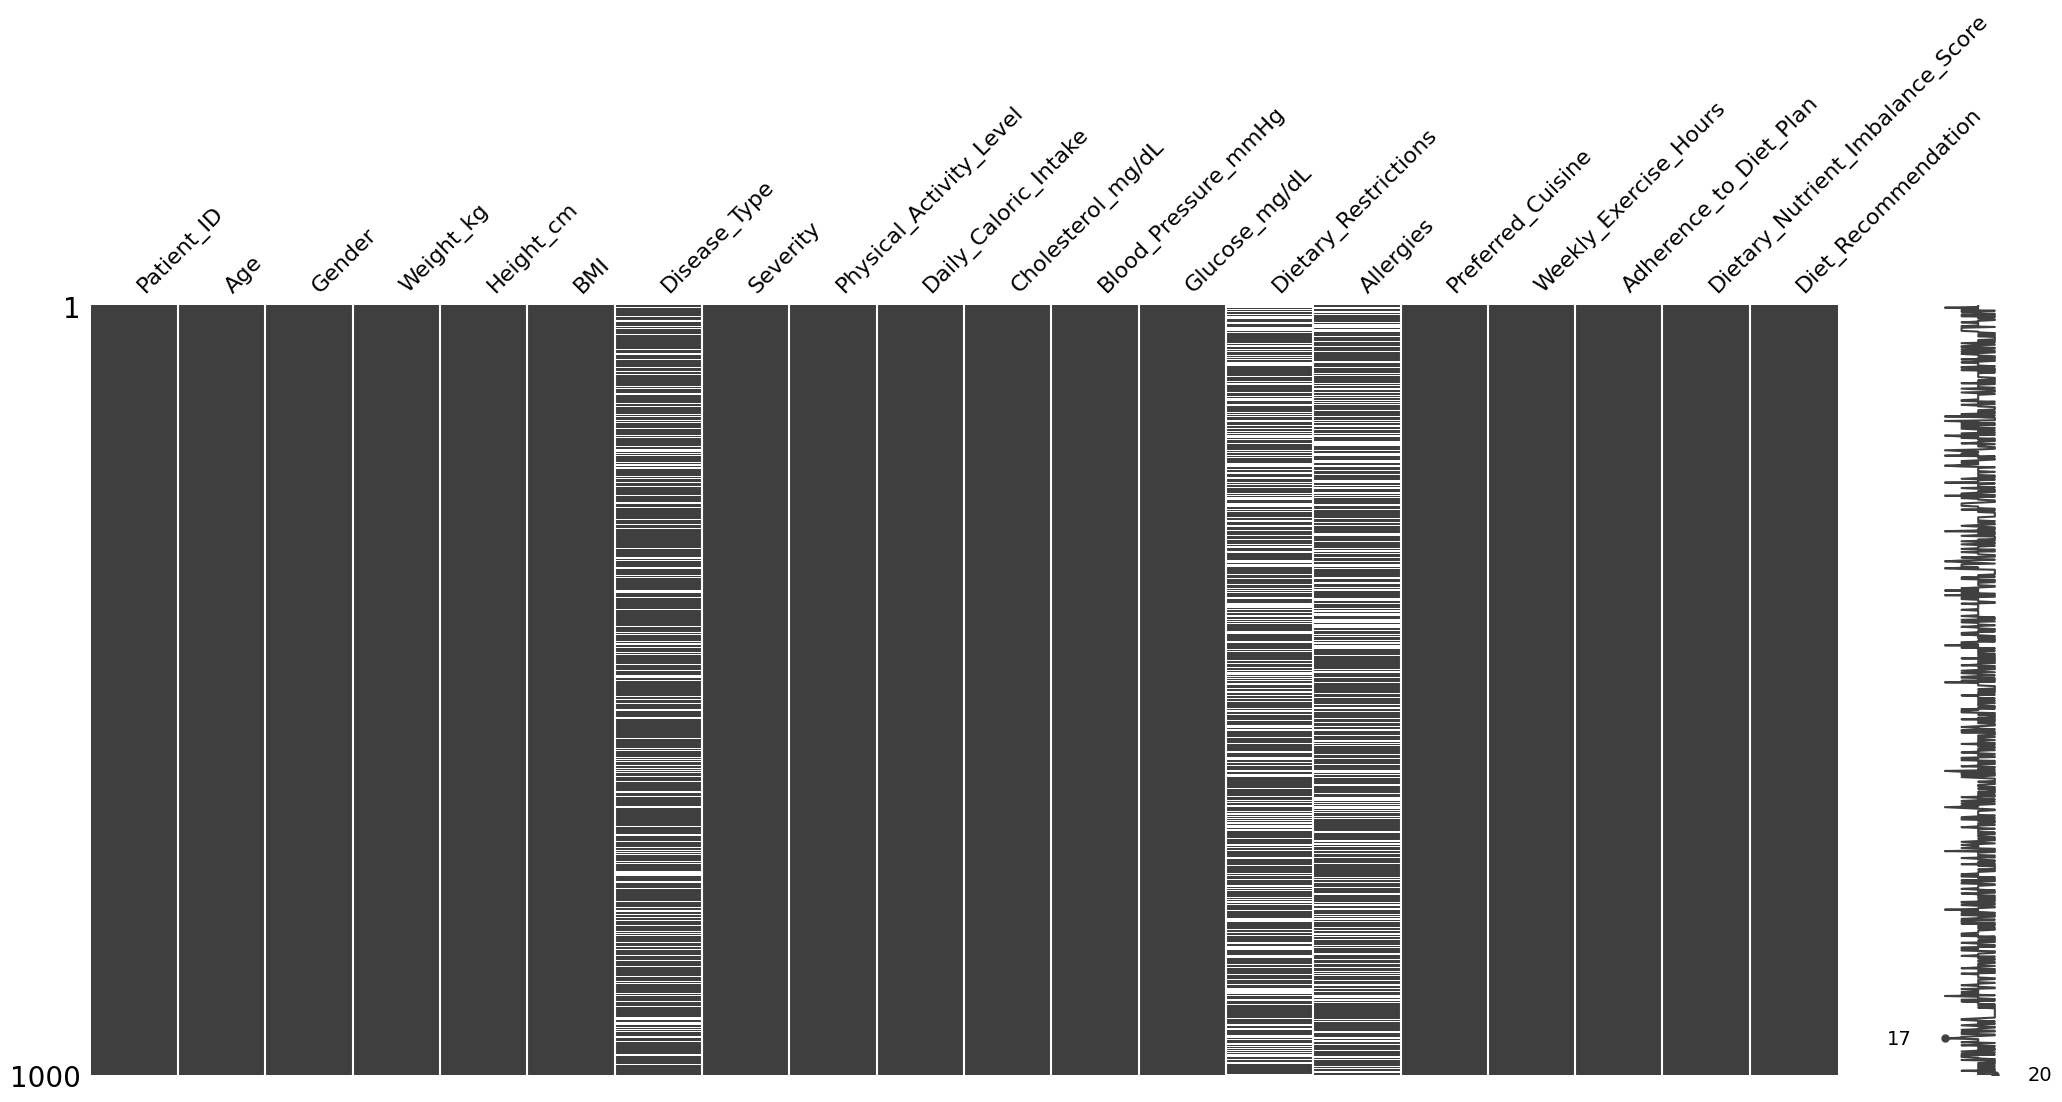

In [76]:
mno.matrix(df) # permet de voir le nombre de valeurs manquates visuelement

In [77]:
df = pd.read_csv("diet_recommendations_dataset.csv", on_bad_lines='skip')

In [78]:
df.shape

(1000, 20)

In [79]:
df.isna().sum()

Patient_ID                            0
Age                                   0
Gender                                0
Weight_kg                             0
Height_cm                             0
BMI                                   0
Disease_Type                        204
Severity                              0
Physical_Activity_Level               0
Daily_Caloric_Intake                  0
Cholesterol_mg/dL                     0
Blood_Pressure_mmHg                   0
Glucose_mg/dL                         0
Dietary_Restrictions                334
Allergies                           323
Preferred_Cuisine                     0
Weekly_Exercise_Hours                 0
Adherence_to_Diet_Plan                0
Dietary_Nutrient_Imbalance_Score      0
Diet_Recommendation                   0
dtype: int64

In [80]:
df.isna().mean()

Patient_ID                          0.000
Age                                 0.000
Gender                              0.000
Weight_kg                           0.000
Height_cm                           0.000
BMI                                 0.000
Disease_Type                        0.204
Severity                            0.000
Physical_Activity_Level             0.000
Daily_Caloric_Intake                0.000
Cholesterol_mg/dL                   0.000
Blood_Pressure_mmHg                 0.000
Glucose_mg/dL                       0.000
Dietary_Restrictions                0.334
Allergies                           0.323
Preferred_Cuisine                   0.000
Weekly_Exercise_Hours               0.000
Adherence_to_Diet_Plan              0.000
Dietary_Nutrient_Imbalance_Score    0.000
Diet_Recommendation                 0.000
dtype: float64

In [81]:
df.dtypes

Patient_ID                              str
Age                                   int64
Gender                                  str
Weight_kg                           float64
Height_cm                             int64
BMI                                 float64
Disease_Type                            str
Severity                                str
Physical_Activity_Level                 str
Daily_Caloric_Intake                  int64
Cholesterol_mg/dL                   float64
Blood_Pressure_mmHg                   int64
Glucose_mg/dL                       float64
Dietary_Restrictions                    str
Allergies                               str
Preferred_Cuisine                       str
Weekly_Exercise_Hours               float64
Adherence_to_Diet_Plan              float64
Dietary_Nutrient_Imbalance_Score    float64
Diet_Recommendation                     str
dtype: object

In [82]:
for i in df.columns:
    if df[i].dtypes == "str":
        print(i + "\n")
        print(df[i].unique())
        print('\n')

Patient_ID

<StringArray>
['P0001', 'P0002', 'P0003', 'P0004', 'P0005', 'P0006', 'P0007', 'P0008',
 'P0009', 'P0010',
 ...
 'P0991', 'P0992', 'P0993', 'P0994', 'P0995', 'P0996', 'P0997', 'P0998',
 'P0999', 'P1000']
Length: 1000, dtype: str


Gender

<StringArray>
['Male', 'Female']
Length: 2, dtype: str


Disease_Type

<StringArray>
['Obesity', 'Diabetes', 'Hypertension', nan]
Length: 4, dtype: str


Severity

<StringArray>
['Moderate', 'Mild', 'Severe']
Length: 3, dtype: str


Physical_Activity_Level

<StringArray>
['Moderate', 'Sedentary', 'Active']
Length: 3, dtype: str


Dietary_Restrictions

<StringArray>
[nan, 'Low_Sugar', 'Low_Sodium']
Length: 3, dtype: str


Allergies

<StringArray>
['Peanuts', nan, 'Gluten']
Length: 3, dtype: str


Preferred_Cuisine

<StringArray>
['Mexican', 'Chinese', 'Italian', 'Indian']
Length: 4, dtype: str


Diet_Recommendation

<StringArray>
['Balanced', 'Low_Carb', 'Low_Sodium']
Length: 3, dtype: str




In [83]:
df.head()

,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Dietary_Restrictions,Allergies,Preferred_Cuisine,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Diet_Recommendation
0,P0001,56,Male,58.4,160,22.8,Obesity,Moderate,Moderate,3079,173.3,133,116.3,NaN,Peanuts,Mexican,3.1,96.6,3.1,Balanced
1,P0002,69,Male,101.2,169,35.4,Diabetes,Mild,Moderate,3032,199.2,120,137.1,NaN,Peanuts,Chinese,4.5,63.2,0.6,Low_Carb
2,P0003,46,Female,63.5,173,21.2,Hypertension,Mild,Sedentary,1737,181.0,121,109.6,NaN,Peanuts,Chinese,3.8,57.5,4.6,Low_Sodium
3,P0004,32,Male,58.1,164,21.6,NaN,Mild,Moderate,2657,168.2,144,159.4,NaN,NaN,Mexican,4.3,54.5,0.4,Balanced
4,P0005,60,Male,79.5,197,20.5,Diabetes,Moderate,Sedentary,3496,200.4,172,182.3,Low_Sugar,NaN,Italian,9.8,78.2,4.7,Low_Carb
